In [4]:
# ==========================================
# STEP 1: LOAD METADATA
# ==========================================

import pandas as pd

print("="*60)
print("[INFO] Loading metadata...")
print("="*60)

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print("[SUCCESS] Metadata loaded successfully.")
print(f"[INFO] Dataset shape: {df.shape}")

print("="*60)

[INFO] Loading metadata...
[SUCCESS] Metadata loaded successfully.
[INFO] Dataset shape: (10015, 7)


In [5]:
# ==========================================
# STEP 2: HANDLE MISSING VALUES
# ==========================================

print("=" * 60)
print("[INFO] Handling missing values...")
print("=" * 60)

missing_before = df["age"].isnull().sum()

print(f"[INFO] Missing values before: {missing_before}")

median_age = df["age"].median()

print(f"[INFO] Median age: {median_age}")

df["age"] = df["age"].fillna(median_age)

missing_after = df["age"].isnull().sum()

print(f"[INFO] Missing values after: {missing_after}")

print("=" * 60)
print("[SUCCESS] Missing values handled successfully.")
print("=" * 60)

[INFO] Handling missing values...
[INFO] Missing values before: 57
[INFO] Median age: 50.0
[INFO] Missing values after: 0
[SUCCESS] Missing values handled successfully.


In [6]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] 57 missing age values detected.")
print("[✓] Median imputation was used.")
print("[✓] No missing values remain.")
print("[✓] Dataset size was preserved.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] 57 missing age values detected.
[✓] Median imputation was used.
[✓] No missing values remain.
[✓] Dataset size was preserved.
[SUCCESS] Observation completed.


In [7]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [8]:
# ==========================================
# STEP 3: LABEL ENCODING
# ==========================================

from sklearn.preprocessing import LabelEncoder

print("=" * 60)
print("[INFO] Encoding target labels...")
print("=" * 60)

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["dx"])

print("[SUCCESS] Labels encoded successfully.")

print("\n[INFO] Label Mapping:")

for class_name, label in zip(label_encoder.classes_,
                             range(len(label_encoder.classes_))):
    print(f"{class_name:<10} → {label}")

print("=" * 60)

[INFO] Encoding target labels...
[SUCCESS] Labels encoded successfully.

[INFO] Label Mapping:
akiec      → 0
bcc        → 1
bkl        → 2
df         → 3
mel        → 4
nv         → 5
vasc       → 6


In [9]:
df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [10]:
# ==========================================
# STEP 4: CREATE IMAGE PATHS
# ==========================================

from pathlib import Path

print("=" * 60)
print("[INFO] Creating image paths...")
print("=" * 60)

image_dir = Path("../data/images")

df["image_path"] = df["image_id"].apply(
    lambda x: str(image_dir / f"{x}.jpg")
)

print("[SUCCESS] Image paths created successfully.")

print("=" * 60)
print("[INFO] Sample paths:")
print("=" * 60)

print(df[["image_id", "image_path"]].head())

print("=" * 60)

[INFO] Creating image paths...
[SUCCESS] Image paths created successfully.
[INFO] Sample paths:
       image_id                       image_path
0  ISIC_0027419  ..\data\images\ISIC_0027419.jpg
1  ISIC_0025030  ..\data\images\ISIC_0025030.jpg
2  ISIC_0026769  ..\data\images\ISIC_0026769.jpg
3  ISIC_0025661  ..\data\images\ISIC_0025661.jpg
4  ISIC_0031633  ..\data\images\ISIC_0031633.jpg


In [11]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Image paths created successfully.")
print("[✓] Each image now has a file location.")
print("[✓] Dataset is ready for PyTorch Dataset class.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Image paths created successfully.
[✓] Each image now has a file location.
[✓] Dataset is ready for PyTorch Dataset class.
[SUCCESS] Observation completed.


In [12]:
# ==========================================
# STEP 5: VERIFY IMAGE FILES
# ==========================================

print("=" * 60)
print("[INFO] Verifying image files...")
print("=" * 60)

from pathlib import Path

df["image_exists"] = df["image_path"].apply(
    lambda x: Path(x).exists()
)

existing_images = df["image_exists"].sum()
missing_images = len(df) - existing_images

print(f"[INFO] Total Images      : {len(df)}")
print(f"[INFO] Existing Images   : {existing_images}")
print(f"[INFO] Missing Images    : {missing_images}")

print("=" * 60)

if missing_images == 0:
    print("[SUCCESS] All image files are present.")
else:
    print("[WARNING] Some images are missing!")

print("=" * 60)

[INFO] Verifying image files...
[INFO] Total Images      : 10015
[INFO] Existing Images   : 10015
[INFO] Missing Images    : 0
[SUCCESS] All image files are present.


In [13]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] All image paths were verified.")
print("[✓] Dataset integrity confirmed.")
print("[✓] Ready for train-validation-test split.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] All image paths were verified.
[✓] Dataset integrity confirmed.
[✓] Ready for train-validation-test split.
[SUCCESS] Observation completed.


# Step 6: Train Validation Test Split

Goal:
- Split dataset into train, validation and test sets.
- Preserve class distribution using stratification.

In [14]:
# ==========================================
# STEP 6.1: TRAIN / TEMPORARY SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("[INFO] Creating training and temporary datasets...")
print("=" * 60)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

print(f"[INFO] Training Samples  : {len(train_df)}")
print(f"[INFO] Temporary Samples : {len(temp_df)}")

print("=" * 60)
print("[SUCCESS] First split completed.")
print("=" * 60)

[INFO] Creating training and temporary datasets...
[INFO] Training Samples  : 7010
[INFO] Temporary Samples : 3005
[SUCCESS] First split completed.


In [15]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] 70% of the dataset allocated to training.")
print("[✓] Remaining 30% stored temporarily.")
print("[✓] Class distribution preserved using stratification.")
print("[✓] Temporary dataset will later be divided into validation and test sets.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] 70% of the dataset allocated to training.
[✓] Remaining 30% stored temporarily.
[✓] Class distribution preserved using stratification.
[✓] Temporary dataset will later be divided into validation and test sets.
[SUCCESS] Observation completed.


In [16]:
# ==========================================
# STEP 6.2: VALIDATION / TEST SPLIT
# ==========================================

print("=" * 60)
print("[INFO] Creating validation and test datasets...")
print("=" * 60)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(f"[INFO] Training Samples   : {len(train_df)}")
print(f"[INFO] Validation Samples : {len(val_df)}")
print(f"[INFO] Test Samples       : {len(test_df)}")

print("=" * 60)
print("[SUCCESS] Dataset splitting completed.")
print("=" * 60)

[INFO] Creating validation and test datasets...
[INFO] Training Samples   : 7010
[INFO] Validation Samples : 1502
[INFO] Test Samples       : 1503
[SUCCESS] Dataset splitting completed.


In [17]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Training set created (70%).")
print("[✓] Validation set created (15%).")
print("[✓] Test set created (15%).")
print("[✓] Class distribution preserved using stratification.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Training set created (70%).
[✓] Validation set created (15%).
[✓] Test set created (15%).
[✓] Class distribution preserved using stratification.
[SUCCESS] Observation completed.


In [18]:
# ==========================================
# STEP 6.3: VERIFY CLASS DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Checking class distribution...")
print("=" * 60)

print("\nTRAIN SET")
print(train_df["dx"].value_counts(normalize=True).round(3))

print("\nVALIDATION SET")
print(val_df["dx"].value_counts(normalize=True).round(3))

print("\nTEST SET")
print(test_df["dx"].value_counts(normalize=True).round(3))

print("\n" + "=" * 60)
print("[SUCCESS] Class distribution verification completed.")
print("=" * 60)

[INFO] Checking class distribution...

TRAIN SET
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.012
Name: proportion, dtype: float64

VALIDATION SET
dx
nv       0.670
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.011
Name: proportion, dtype: float64

TEST SET
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.015
df       0.011
Name: proportion, dtype: float64

[SUCCESS] Class distribution verification completed.


# Step 7: Image Transformations

Goal:
- Resize images to 224×224.
- Apply data augmentation to training images.
- Normalize images using ImageNet statistics.

In [19]:
# ==========================================
# STEP 7: IMAGE TRANSFORMATIONS
# ==========================================

from torchvision import transforms

print("=" * 60)
print("[INFO] Creating image transformations...")
print("=" * 60)

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Validation/Test transformations
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = val_transform

print("[SUCCESS] Image transformations created successfully.")
print("=" * 60)

[INFO] Creating image transformations...
[SUCCESS] Image transformations created successfully.


In [20]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Images resized to 224×224.")
print("[✓] Data augmentation enabled for training.")
print("[✓] Validation and test images remain unchanged.")
print("[✓] ImageNet normalization applied.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Images resized to 224×224.
[✓] Data augmentation enabled for training.
[✓] Validation and test images remain unchanged.
[✓] ImageNet normalization applied.
[SUCCESS] Observation completed.


In [21]:
from torch.utils.data import Dataset
from PIL import Image

In [22]:
# ==========================================
# STEP 8: CUSTOM DATASET CLASS
# ==========================================

class HAM10000Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        # Image path
        image_path = self.dataframe.iloc[idx]["image_path"]

        # Label
        label = self.dataframe.iloc[idx]["label"]

        # Open image
        image = Image.open(image_path).convert("RGB")

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

In [23]:
# ==========================================
# STEP 8.1: CREATE DATASET OBJECTS
# ==========================================

print("=" * 60)
print("[INFO] Creating dataset objects...")
print("=" * 60)

train_dataset = HAM10000Dataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    transform=val_transform
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    transform=test_transform
)

print(f"[INFO] Training Images   : {len(train_dataset)}")
print(f"[INFO] Validation Images : {len(val_dataset)}")
print(f"[INFO] Test Images       : {len(test_dataset)}")

print("=" * 60)
print("[SUCCESS] Dataset objects created successfully.")
print("=" * 60)

[INFO] Creating dataset objects...
[INFO] Training Images   : 7010
[INFO] Validation Images : 1502
[INFO] Test Images       : 1503
[SUCCESS] Dataset objects created successfully.


In [24]:
# ==========================================
# STEP 9: TEST DATASET
# ==========================================

print("=" * 60)
print("[INFO] Testing dataset...")
print("=" * 60)

image, label = train_dataset[0]

print(f"[INFO] Image Shape : {image.shape}")
print(f"[INFO] Label       : {label}")

print("=" * 60)
print("[SUCCESS] Dataset test completed.")
print("=" * 60)

[INFO] Testing dataset...
[INFO] Image Shape : torch.Size([3, 224, 224])
[INFO] Label       : 5
[SUCCESS] Dataset test completed.


In [25]:
# ==========================================
# STEP 9.1: CREATE DATALOADERS
# ==========================================

from torch.utils.data import DataLoader
import torch

print("=" * 60)
print("[INFO] Creating DataLoaders...")
print("=" * 60)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # Windows + VS Code + Jupyter safe
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"[INFO] Number of training batches   : {len(train_loader)}")
print(f"[INFO] Number of validation batches : {len(val_loader)}")
print(f"[INFO] Number of test batches       : {len(test_loader)}")

print("=" * 60)
print("[SUCCESS] DataLoaders created successfully.")
print("=" * 60)

[INFO] Creating DataLoaders...
[INFO] Number of training batches   : 220
[INFO] Number of validation batches : 47
[INFO] Number of test batches       : 47
[SUCCESS] DataLoaders created successfully.


In [26]:
# ==========================================
# STEP 10: TEST DATALOADER
# ==========================================

print("=" * 60)
print("[INFO] Testing DataLoader...")
print("=" * 60)

images, labels = next(iter(train_loader))

print(f"[INFO] Images Shape : {images.shape}")
print(f"[INFO] Labels Shape : {labels.shape}")

print("=" * 60)
print("[SUCCESS] DataLoader test completed.")
print("=" * 60)

[INFO] Testing DataLoader...
[INFO] Images Shape : torch.Size([32, 3, 224, 224])
[INFO] Labels Shape : torch.Size([32])
[SUCCESS] DataLoader test completed.


In [27]:
# ==========================================
# STEP 11: COMPUTE CLASS WEIGHTS
# ==========================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

print("=" * 60)
print("[INFO] Computing class weights...")
print("=" * 60)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("[INFO] Class Weights:")

for idx, weight in enumerate(class_weights):
    print(f"Class {idx} : {weight:.4f}")

print("=" * 60)
print("[SUCCESS] Class weights computed successfully.")
print("=" * 60)

[INFO] Computing class weights...
[INFO] Class Weights:
Class 0 : 4.3731
Class 1 : 2.7817
Class 2 : 1.3022
Class 3 : 12.3633
Class 4 : 1.2855
Class 5 : 0.2134
Class 6 : 10.1154
[SUCCESS] Class weights computed successfully.


[INFO] Visualizing a batch of images...


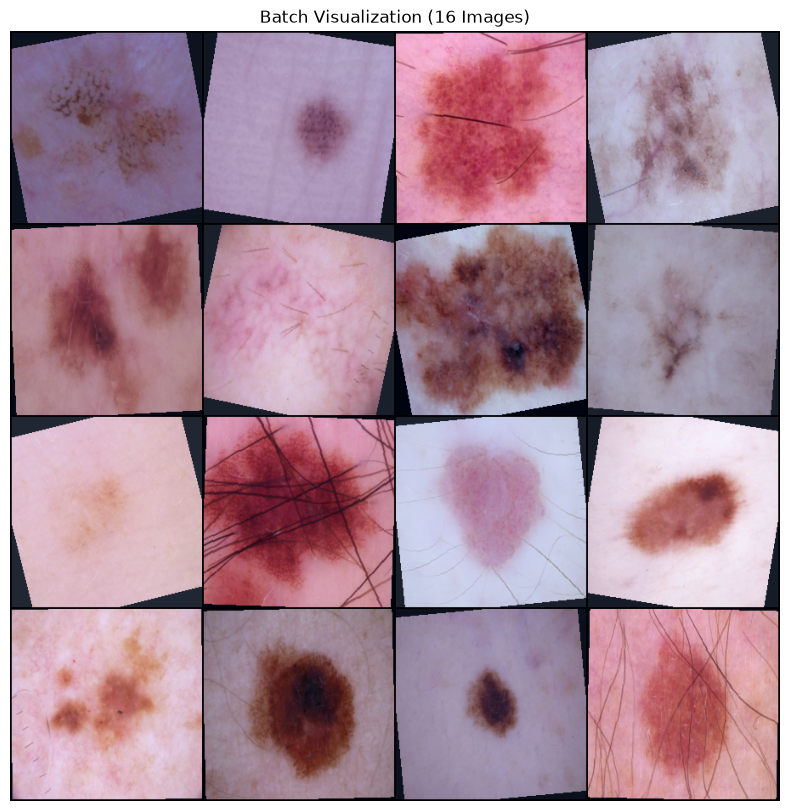

[SUCCESS] Batch visualization completed.


In [28]:
# ==========================================
# STEP 10.1: BATCH VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import torchvision

print("=" * 60)
print("[INFO] Visualizing a batch of images...")
print("=" * 60)

# Get one batch
images, labels = next(iter(train_loader))

# Create grid
grid = torchvision.utils.make_grid(
    images[:16],
    nrow=4,
    normalize=True
)

plt.figure(figsize=(10,10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Batch Visualization (16 Images)")
plt.show()

print("[SUCCESS] Batch visualization completed.")
print("=" * 60)

In [29]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Images loaded successfully.")
print("[✓] Data augmentation is working.")
print("[✓] Images are resized to 224×224.")
print("[✓] Batch generation verified.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Images loaded successfully.
[✓] Data augmentation is working.
[✓] Images are resized to 224×224.
[✓] Batch generation verified.
[SUCCESS] Observation completed.
